#OrganoMind

##Introduction

The following Jupyter notebook aims to present **OrganoMind**, a pip-installable package designed as an organic Chemistry assistant. The idea behind this package is to provide chemists with a tool to better predict organic reaction outcomes by developing an understanding of molecular reactivity, based on nucleophilic and electrophilic character as well as acid-base properties and functional group identification. OrganoMind also allows chemists to improve their molecular visualization by displaying a 3D representation of molecule and 2D identification of chiral center on the molecule. OrganoMind is mainly built using rdkit, pubchempy and streamlit packages combined with other specific packages, whose installation is detailled in the readme.

This package was created as a collaborative project for the EPFL course *Practical Programming in Chemistry*.

Before delving into the code and the various features offered by OrganoMind, let’s explore the motivations behind this project as well as the chemistry principles used to build the package.

##Motivation

In organic chemistry, when faced with a reaction that needs to be completed, the most important thing is to understand which factors can influence it. From this challenge emerged OrganoMind. 

We wanted to developp a tool which would allows chemists from all around the world to deal with the difficulties of finding the reactive sites of a molecule and therefore gain time when working on organic chemistry reaction. We needed first to define all the thing a molecule posseses that can influence a reaction. From this refelction, we have choosen to focus on the following element: The chirality of the molecule, the detection of the functional groups, as well of potential acidic/basic group and nucleophilic/electrophilic group. Functions, which are implemented in a streamlit UI or can be used seperatly, were developped for each of these elements. **Need to continue**

#Usage of OrganoMind 

Once the package installed, users can take advantage of the full rnage of functions offer by OrganoMind. A function is designed for each molecular characteristic and the section below will outlined the usage of these functions by applying examples.

##Stereochemistry
###`chiral_center()`
This function determines the number of chiral centers in a molecule. It parses the input SMILES string and converts it into an RDKit molecule object using `Chem.MolFromSmiles()`. The chiral centers are then identified using `Chem.FindMolChiralCenters()` with includeUnassigned=True, which returns a list of tuples containing the index and configuration (R/S) of each chiral center. The number of chiral centers is obtained by counting the elements in this list.

In [8]:
from functions.stereo import chiral_center

chrial_result = chiral_center("CCC(C)(CCC(C)(CO)N)O")

print(chrial_result)

2


###`find_isomers()`
This function determines the number of stereoisomers of the input molecule. It parses the SMILES string and converts it into an RDKit molecule object using `Chem.MolFromSmiles()`. The enumeration options are then set with `StereoEnumerationOptions()`, with unique=True to avoid duplicates, onlyUnassigned=False to consider all stereocenters, and tryEmbedding=True to ensure each isomer is physically realistic in 3D. The number of stereoisomers is then determined by counting the elements in the tuple returned by `EnumerateStereoisomers()`. Note: if only one configuration of the molecule exists, the function will return 1.

In [9]:
from functions.stereo import find_isomers

isomer_result = find_isomers("CCC(C)(CCC(C)(CO)N)O")

print(isomer_result)

4


###`color_chiral()`
This function takes a SMILES string as input and represents the molecule as a 2D structure with its chiral atoms highlighted in green. First, the SMILES string is converted into an RDKit molecule object using Chem.MolFromSmiles(). If the SMILES is invalid, a ValueError is raised. The chiral centers are then identified using Chem.FindMolChiralCenters() with includeUnassigned=True, which returns a list of tuples containing the index and the configuration (R/S) of each chiral atom. The atom indices are extracted from this list and passed to Draw.MolToImage(), which generates a 2D depiction of the molecule with the chiral atoms highlighted in green. If no chiral centers are found, the function returns None.

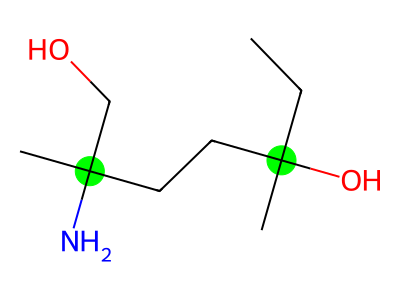

In [1]:
from functions.stereo import color_chiral
from IPython.display import display

img = color_chiral("CCC(C)(CCC(C)(CO)N)O")
display(img)

##Aromatic groups
###`detect_aromatic()`
This function detects whether aromatic groups are present in a molecule and, if so, returns a DataFrame containing the name of each aromatic group, the number of times it appears in the molecule, and its position. A dictionary called aromatic_patterns serving as a database was created beforehand, containing aromatic group names as keys and their corresponding precompiled RDKit pattern objects as values. The input SMILES string is first converted into an RDKit molecule object using `Chem.MolFromSmiles()`. The function then iterates through the dictionary and uses `GetSubstructMatches()` to check if each pattern is present in the molecule. The matches are collected into a list and returned as a pandas DataFrame. If no aromatic group is detected, the function returns an empty DataFrame with a 'None' entry.

In [4]:
from functions.aromatic import detect_aromatic

result_aromatic = detect_aromatic("C1=CC=C(C=C1)C(C2=CC=C(C=C2)CC3=COC=C3)C4=CNC=C4")

result_aromatic

,Aromatic Group,Count,Position
0,benzene,2,"[[0, 1, 2, 3, 4, 5], [7, 8, 9, 10, 11, 12]]"
1,furan,1,"[[14, 18, 17, 16, 15]]"
2,pyrrole,1,"[[19, 23, 22, 21, 20]]"
